In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if (Path.cwd().name == 'notebooks') else Path.cwd()
print('Project root:', PROJECT_ROOT)
print('Python:', sys.executable)


Project root: c:\Users\lakshmi.prasanna\OneDrive - insightsoftware\Documents\prashanth\MTECH\SEMESTER3\New folder\MLsysOps_Assignment
Python: c:\Users\lakshmi.prasanna\AppData\Local\Programs\Python\Python312\python.exe


## 1) Run the pipeline (download → preprocess → EDA → train)

This produces:
- `data/raw/heart_disease.csv`
- `artifacts/eda/*` (plots)
- `artifacts/mlruns/*` (MLflow runs)
- `artifacts/model/model.joblib`

In [4]:
import subprocess

# NOTE: If this notebook is running with your *system* Python, the pipeline module may not exist there.
# This cell prefers the repo's local venv interpreter at `../.venv/Scripts/python.exe` on Windows.

venv_python = (PROJECT_ROOT / ".venv" / "Scripts" / "python.exe").resolve()
python_exe = str(venv_python) if venv_python.exists() else sys.executable

print("Using python:", python_exe)
print("Project root:", PROJECT_ROOT)

# If UCI HTTPS fails on a corporate network, you can uncomment this:
# os.environ['UCI_ALLOW_INSECURE_SSL'] = '1'

cmd = [python_exe, "-m", "heart_disease_mlops.pipeline", "run"]
print("Running:", " ".join(cmd))

# Jupyter can set a Matplotlib inline backend that requires IPython inside the subprocess env.
# Force a safe headless backend for the pipeline subprocess.
env = os.environ.copy()
env["MPLBACKEND"] = "Agg"

# Capture output so the error is visible in the notebook if it fails.
completed = subprocess.run(
    cmd,
    cwd=str(PROJECT_ROOT),
    env=env,
    text=True,
    capture_output=True,
    shell=False,
 )
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise SystemExit(f"Pipeline failed with exit code {completed.returncode}")

Using python: C:\Users\lakshmi.prasanna\OneDrive - insightsoftware\Documents\prashanth\MTECH\SEMESTER3\New folder\MLsysOps_Assignment\.venv\Scripts\python.exe
Project root: c:\Users\lakshmi.prasanna\OneDrive - insightsoftware\Documents\prashanth\MTECH\SEMESTER3\New folder\MLsysOps_Assignment
Running: C:\Users\lakshmi.prasanna\OneDrive - insightsoftware\Documents\prashanth\MTECH\SEMESTER3\New folder\MLsysOps_Assignment\.venv\Scripts\python.exe -m heart_disease_mlops.pipeline run




## 2) Load the cleaned dataset

In [5]:
raw_csv = PROJECT_ROOT / 'data' / 'raw' / 'heart_disease.csv'
df = pd.read_csv(raw_csv)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3) Quick EDA (class balance + correlation heatmap)

Note: The pipeline already writes professional plots to `artifacts/eda/`. This section just shows how to do the same inside the notebook.

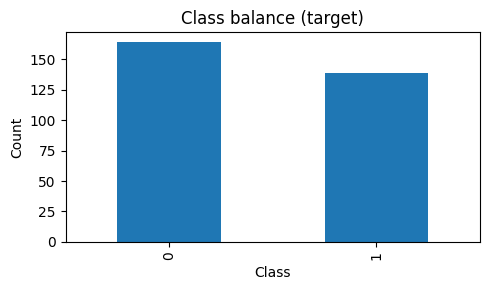

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = 'target'
fig, ax = plt.subplots(figsize=(5, 3))
df[target_col].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Class balance (target)')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

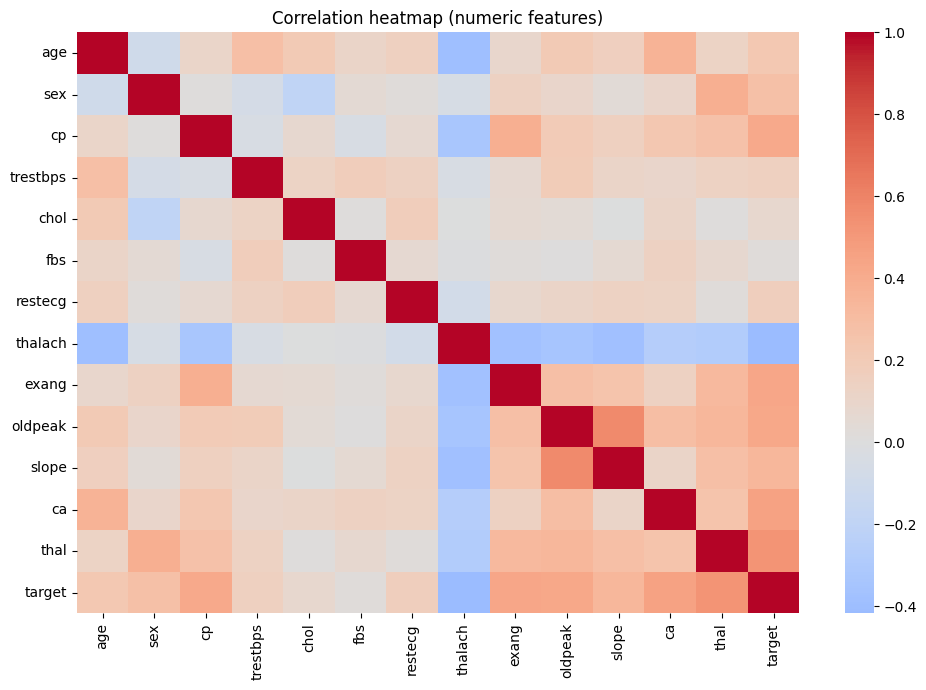

In [7]:
# Correlation heatmap for numeric columns
num_df = df.select_dtypes(include=['number']).copy()
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric features)')
plt.tight_layout()
plt.show()

## 4) Local inference (load the packaged model and predict)

This verifies the saved reusable model pipeline (`artifacts/model/model.joblib`) without any web server.

In [ ]:
import json
import subprocess

# This model is pickled with scikit-learn from the repo's `.venv`.
# If your notebook kernel is NOT the same environment, `joblib.load()` can fail with sklearn AttributeError.
# So we run inference in a subprocess using the same `.venv` Python used for training.

model_path = (PROJECT_ROOT / "artifacts" / "model" / "model.joblib").resolve()
venv_python = (PROJECT_ROOT / ".venv" / "Scripts" / "python.exe").resolve()
python_exe = str(venv_python) if venv_python.exists() else sys.executable

sample = {
    "age": 63,
    "sex": 1,
    "cp": 3,
    "trestbps": 145,
    "chol": 233,
    "fbs": 1,
    "restecg": 0,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 2.3,
    "slope": 0,
    "ca": 0,
    "thal": 1,
}

code = f"""
import json
import joblib
import pandas as pd
from pathlib import Path

model = joblib.load(r'{model_path}')
sample = json.loads(r'''{json.dumps(sample)}''')
X = pd.DataFrame([sample])
proba = float(model.predict_proba(X)[:, 1][0])
pred = int(proba >= 0.5)
print(json.dumps({{'prediction': pred, 'confidence': proba}}))
"""

cmd = [python_exe, "-c", code]
completed = subprocess.run(cmd, cwd=str(PROJECT_ROOT), text=True, capture_output=True)
if completed.returncode != 0:
    print(completed.stdout)
    print(completed.stderr)
    raise SystemExit(f"Inference subprocess failed with exit code {completed.returncode}")

result = json.loads(completed.stdout.strip())
result

c:\Users\lakshmi.prasanna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.6.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\lakshmi.prasanna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\lakshmi.prasanna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWar

AttributeError: Can't get attribute '_RemainderColsList' on <module 'sklearn.compose._column_transformer' from 'c:\\Users\\lakshmi.prasanna\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\sklearn\\compose\\_column_transformer.py'>

## 5) API inference (optional)

If you started Uvicorn separately (example: `http://127.0.0.1:8001`), this cell calls `/healthz` and `/predict`.

In [ ]:
import urllib.request
import json

base = os.environ.get('API_BASE', 'http://127.0.0.1:8001')

with urllib.request.urlopen(f'{base}/healthz', timeout=5) as resp:
    print('GET /healthz', resp.status, resp.read().decode('utf-8'))

payload = sample
data = json.dumps(payload).encode('utf-8')
req = urllib.request.Request(
    f'{base}/predict',
    data=data,
    headers={'Content-Type': 'application/json'},
    method='POST',
)
with urllib.request.urlopen(req, timeout=10) as resp:
    print('POST /predict', resp.status, resp.read().decode('utf-8'))